# 14.2.1 配对快照与线性传播

## 学习目标与先修知识

从相邻快照拟合传播矩阵（matrix），比较训练一步残差（residual）和独立初值（initial condition）的滚动误差。

先修：14.1 投影（projection）与新初值；6.5 动态辨识；最小二乘和矩阵乘法（matrix multiplication）。

## 具体问题

同一三室系统的相邻时刻可以排成两组矩阵。能否由“现在→下一步”的配对快照识别传播规则？训练残差小能否保证新初值的多步预测？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import font_manager
from systems_science import plot_style
plot_style()
font_names={font.name for font in font_manager.fontManager.ttflist}
for name in ("Microsoft YaHei","SimHei","Noto Sans CJK SC"):
    if name in font_names:
        plt.rcParams["font.sans-serif"]=[name,"DejaVu Sans"]
        break
BLUE,PINK,GREEN="#008bfb","#ff0051","#00a56a"

## 初步实验

先看一维指数序列，相邻快照的比值给出离散一步传播倍数。

In [2]:
x=np.array([2.,1.6,1.28,1.024]);print('相邻比值：',x[1:]/x[:-1])

相邻比值： [0.8 0.8 0.8]


## 模型假设

在固定采样（sampling）间隔 Δt 下，列 X 是旧状态（state），列 Y 是相应的新状态；配对与单位必须一致。先在无噪声的已知线性模型（model）上核验，再讨论数据不足。训练快照之外的新初值仅用于预测评价。

## 数学解释与推导

设 $X=[x_0,\ldots,x_{m-1}]$、$Y=[x_1,\ldots,x_m]$，用 $Y\approx AX$ 最小化 $\|Y-AX\|_F^2$。最小范数（norm）解为 $A=YX^+$；若 $X=U\Sigma V^\mathsf T$，截断到 $r$ 个可辨方向则 $A_r=YV_r\Sigma_r^{-1}U_r^\mathsf T$。零奇异值（singular value）不能求倒数，本节将其逆置零。动态模态分解（dynamic mode decomposition，DMD）从这一传播算子及其特征结构出发。若训练列不覆盖某方向，对该方向的传播无法由当前数据唯一确定；一步拟合和新初值滚动验证必须分开。

## 核心实现

以下是本节完整计算步骤，可逐行修改。

In [3]:
def dmd_fit(past, future, rank):
    """Fit Y X_r^+ with zero singular directions discarded."""
    x = np.asarray(past, dtype=float)
    y = np.asarray(future, dtype=float)
    left, singular, right_t = np.linalg.svd(x, full_matrices=False)
    keep = min(rank, len(singular))
    if keep == 0:
        return np.zeros((x.shape[0], x.shape[0])).tolist()
    cutoff = 1e-12 * singular[0]
    inverse = np.divide(1., singular[:keep],
                        out=np.zeros(keep), where=singular[:keep] > cutoff)
    operator = (y @ right_t[:keep].T * inverse) @ left[:, :keep].T
    return operator.tolist()


def linear_roll(operator, initial, steps):
    """Include the initial state, then repeatedly apply a fixed operator."""
    matrix = np.asarray(operator, dtype=float)
    state = np.asarray(initial, dtype=float)
    history = [state.tolist()]
    for _ in range(steps):
        state = matrix @ state
        history.append(state.tolist())
    return history

## 对照实验

用已知二变量传播矩阵产生训练快照，比较满秩（rank）与秩1 拟合；再以未参加拟合的初值滚动预测。

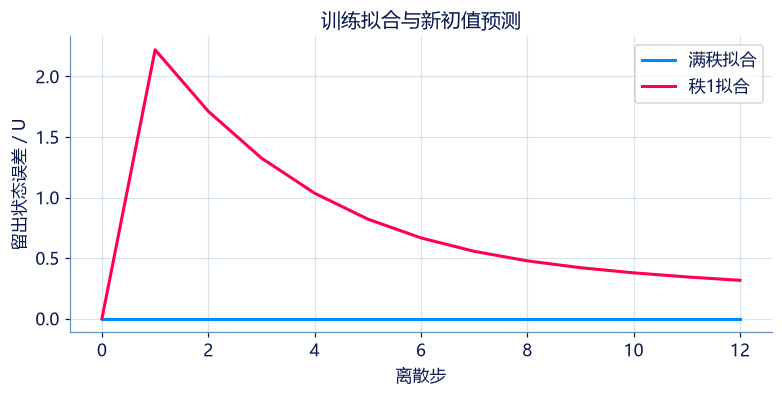

满秩传播矩阵： [[0.9 0.1]
 [0.  0.8]]
秩1训练一步残差： 0.37070772977614297


In [4]:
A=np.array([[.9,.1],[0.,.8]])
state=np.array([2.,1.]);train=[state.copy()]
for _ in range(8):state=A@state;train.append(state.copy())
X=np.asarray(train[:-1]).T;Y=np.asarray(train[1:]).T
fit=np.asarray(dmd_fit(X,Y,2));low=np.asarray(dmd_fit(X,Y,1))
held=np.array([0.,3.]);truth=np.asarray(linear_roll(A,held,12));full=np.asarray(linear_roll(fit,held,12));cut=np.asarray(linear_roll(low,held,12))
fig,ax=plt.subplots(figsize=(7,3.5));ax.plot(np.linalg.norm(full-truth,axis=1),label='满秩拟合',color=BLUE);ax.plot(np.linalg.norm(cut-truth,axis=1),label='秩1拟合',color=PINK)
ax.set(xlabel='离散步',ylabel='留出状态误差 / U',title='训练拟合与新初值预测');ax.grid(alpha=.25);ax.legend();plt.show()
print('满秩传播矩阵：',np.round(fit,6));print('秩1训练一步残差：',np.linalg.norm(Y-low@X))

## 结果解释

这组线性快照覆盖两个独立方向，满秩 DMD 能恢复传播矩阵；秩1 丢掉一个方向，新初值的误差随后显现。若只有一条退化轨迹（trajectory），训练残差为零仍不表示未观测（observation）方向已被识别。

### 独立核对

将满秩结果与事先给定的传播矩阵独立比较；秩0、零奇异方向与初值长度另核对。

In [5]:
np.testing.assert_allclose(fit,A,atol=1e-10)
np.testing.assert_allclose(truth,full,atol=1e-10)
np.testing.assert_allclose(dmd_fit([[1.,0.],[0.,0.]],[[.5,0.],[0.,0.]],2),[[.5,0.],[0.,0.]],atol=1e-12)
assert np.asarray(dmd_fit(X,Y,0)).shape==(2,2)
print('独立矩阵、零方向与秩0检查通过。')

独立矩阵、零方向与秩0检查通过。


[在本章探索中改变条件](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/explore/)，再返回此处核对完整推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：从配对快照拟合传播矩阵

past 和 future 的第 j 列是同一轨迹（trajectory）相邻时刻。按题定截断伪逆（pseudoinverse）返回 n×n 的一步传播矩阵（matrix）；不必返回奇异向量（vector）。

**函数与代码模板**

```python
def solve(
    past: list[list[float]],
    future: list[list[float]],
    rank: int,
) -> list[list[float]]:
    # 按题意计算并返回结果。
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `past` | `list[list[float]]` | n×m 旧状态（state）快照，按列配对。 | U |
| `future` | `list[list[float]]` | n×m 下一步快照。 | U |
| `rank` | `int` | 保留的左奇异方向数，允许0。 | 个 |

**返回值**

直接返回 operator（list[list[float]]）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `operator` | `list[list[float]]` | 使 future≈operator·past 的 n×n 算子。 | 1 |

**计算规则**

对 past 作 SVD，取前 rank 个奇异方向；逆奇异值（singular value）只用于大于首奇异值的 10⁻¹² 倍的项，其余逆置零。rank=0 时返回零矩阵。若在重复奇异值处截断，最优方向可不唯一；本题非端点截断只给严格间隙。

**约束与边界**

- n≥1，m≥1，0≤rank≤min(n,m)；非端点截断处有严格奇异值间隙。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| past | n×m 旧状态（state）快照，按列配对。 | [[1.0, 0.0], [0.0, 1.0]] | U |
| future | n×m 下一步快照。 | [[0.9, 0.1], [0.0, 0.8]] | U |
| rank | 保留的左奇异方向数，允许0。 | 2 | 个 |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
past = [[1.0, 0.0], [0.0, 1.0]]
future = [[0.9, 0.1], [0.0, 0.8]]
rank = 2

result = solve(past, future, rank)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| operator | 使 future≈operator·past 的 n×n 算子。 | [[0.9, 0.1], [0.0, 0.8]] | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = [[0.9, 0.1], [0.0, 0.8]]
```

**样例解释**

首例 past 是单位矩阵（identity matrix），所以返回的算子就是 future；秩（rank）不足时不能从数据确定未激发方向。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-07。

[作答：从配对快照拟合传播矩阵](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/practice/?question=p14-dmd-fit)

### 第 2 题 · 单项选择题：一步好不等于滚动好

训练配对快照的一步残差（residual）很小。哪项结论仍需另行检验？

- **A.** 新初值（initial condition）的多步预测误差。
- **B.** 传播矩阵（matrix）已经是真实机制。
- **C.** 任意初值必有零预测误差。
- **D.** 可以忽略快照配对顺序。

[作答：一步好不等于滚动好](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/practice/?question=p14-one-step-rollout)

### 第 3 题 · 单项选择题：未激发方向的传播

训练快照只沿一个方向变化，却要预测二维新初值（initial condition）。哪项判断正确？

- **A.** 另一个方向上的传播不能由这批快照唯一识别。
- **B.** 零训练误差给出完整二维算子。
- **C.** 把 rank 改为2 必自动产生第二条独立信息。
- **D.** 舍弃奇异值（singular value）一定为负。

[作答：未激发方向的传播](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/practice/?question=p14-null-direction)

### 第 4 题 · 单项选择题：配对列的时间含义

构造 X 与 Y 时，下列哪一项保持了同一采样（sampling）间隔的一步配对？

- **A.** X 的第 j 列取 x_j，Y 的第 j 列取 x_(j+1)。
- **B.** X 与 Y 各自随机打乱列。
- **C.** 把留出初值（initial condition）也放入 X 后仍称其为独立测试。
- **D.** X 用总量，Y 不声明地改用浓度（concentration）。

[作答：配对列的时间含义](http://127.0.0.1:8000/chapters/14-02-%E5%8A%A8%E6%80%81%E6%A8%A1%E6%80%81%E5%88%86%E8%A7%A3/practice/?question=p14-paired-columns)

**进一步阅读**

[Schmid 的 DMD 论文](https://doi.org/10.1017/S0022112010001217)介绍流动快照中的动态模态；本节采用完全给定的教学线性系统。